Note: you may need to restart the kernel to use updated packages.
Found existing installation: pandas 2.3.3
Uninstalling pandas-2.3.3:
  Successfully uninstalled pandas-2.3.3
Found existing installation: pyarrow 22.0.0
Uninstalling pyarrow-22.0.0:
  Successfully uninstalled pyarrow-22.0.0
Found existing installation: fastparquet 2024.11.0
Uninstalling fastparquet-2024.11.0:
  Successfully uninstalled fastparquet-2024.11.0
Note: you may need to restart the kernel to use updated packages.
  Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
  Using cached pyarrow-22.0.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (3.2 kB)
  Using cached fastparquet-2024.11.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.2 kB)
Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (12.4 MB)
Using cached pyarrow-22.0.0-cp312-cp312-manylinux_2_28_x86_64.whl (47.7 MB)
Using cached fastparquet-2024.1

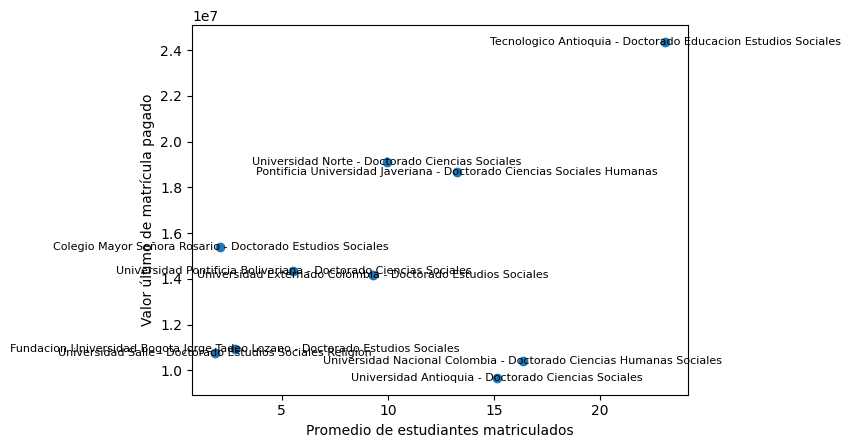

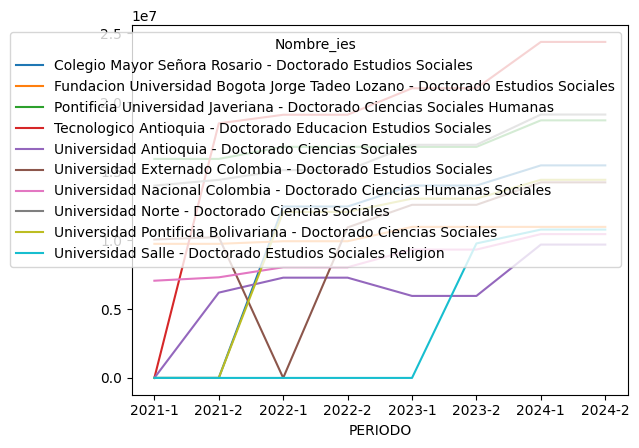

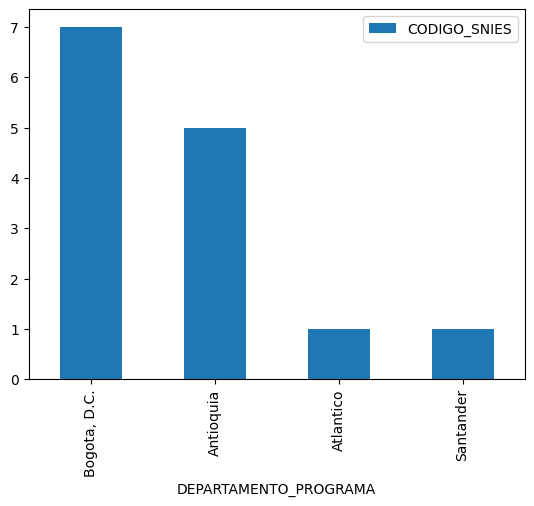

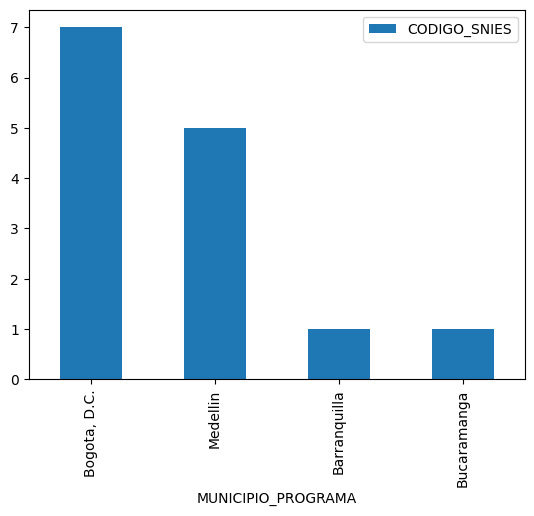

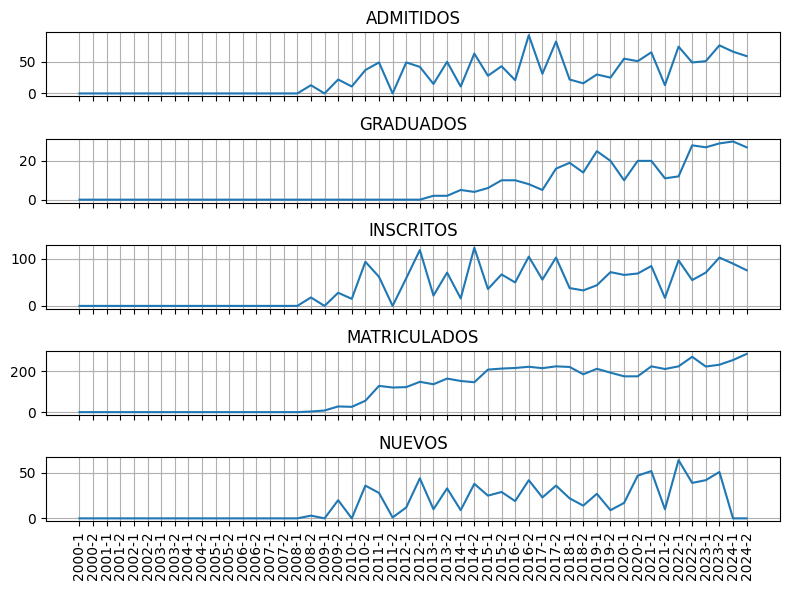

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

programa='DOCTORADO CIENCIAS SOCIALES'
requerido=set(['doctorado', 'sociales'])
programa=set(programa.lower().split())
n=len(programa)

# Ejecutar en una celda del notebook (asegura instalación en el kernel activo)
# asegurar instalación correcta en el kernel activo (ejecutar en Jupyter)
%pip install --upgrade pip
%pip uninstall -y pandas pyarrow fastparquet
%pip install --upgrade pandas pyarrow fastparquet

maestro = pd.read_parquet('https://robertohincapie.com/data/snies/MAESTRO.parquet')
oferta=pd.read_parquet('https://robertohincapie.com/data/snies/OFERTA.parquet')
programas=pd.read_parquet('https://robertohincapie.com/data/snies/PROGRAMAS.parquet')
ies=pd.read_parquet('https://robertohincapie.com/data/snies/IES.parquet')
equivalentes=[]
for prg in programas['PROGRAMA_ACADEMICO'].unique():
    prg2=str(prg).lower().split()
    indice=len(set(programa).intersection(prg2))/len(programa)
    if(indice>=(n-1)/n and len(requerido.intersection(prg2))==len(requerido)):
        equivalentes.append(prg)
programas2=programas[programas['PROGRAMA_ACADEMICO'].isin(equivalentes)]
snies2=list(programas2['CODIGO_SNIES'].unique())
maestro2=maestro[maestro['CODIGO_SNIES'].isin(snies2)]
#data=maestro[(maestro['CODIGO_SNIES']=='109887')]
#Num_est=data[data['PROXY_PER']=='20231'][['GENERO','PROCESO','CANTIDAD']]
#maestro.merge(right=programas, left_on='CODIGO_SNIES', right_on='CODIGO_SNIES', how='left')
institucion={ies:name for ies,name in programas[['IES_PADRE','INSTITUCION']].values if str(ies) not in ['null','Nan']}
maestro3=maestro2.merge(programas, left_on='CODIGO_SNIES', right_on='CODIGO_SNIES', how='left')
maestro4=maestro3.merge(oferta, on=['CODIGO_SNIES', 'PERIODO'], how='left')

#Primera gráfica: Número de programas e instituciones en el tiempo
NprogNies=maestro4.groupby(by='PERIODO').agg({'CODIGO_INSTITUCION_x':'nunique', 'CODIGO_SNIES':'nunique'})

#Segunda gráfica, costo del programa en 2024 vs el promedio de matriculados entre 2021-2023
maestro4['PROXY_PER']=maestro4['PROXY_PER'].astype(int)
df=maestro4[(maestro4['PROXY_PER']>=20211) & (maestro4['PROXY_PER']<=20242)].copy()
df.loc[:,'Nombre_ies']=df['INSTITUCION']+' - '+df['PROGRAMA_ACADEMICO']
df=df[df['PROCESO']=='MATRICULADOS'].copy()
df['CANTIDAD']=df['CANTIDAD'].astype(int)
df=df[['MATRICULA','CANTIDAD','Nombre_ies','PERIODO']]
df=df.dropna()
df=df[df['MATRICULA']!='null'].copy()
df['MATRICULA']=df['MATRICULA'].astype(float)
df2=df.groupby(by='Nombre_ies').agg({'MATRICULA':'last', 'CANTIDAD':'mean'})


plt.scatter(df2['CANTIDAD'], df2['MATRICULA'])
for i, txt in enumerate(df2.index):
    plt.text(df2['CANTIDAD'].iloc[i], df2['MATRICULA'].iloc[i], str(txt),
             fontsize=8, ha='center', va='center')
plt.xlabel('Promedio de estudiantes matriculados')
plt.ylabel('Valor último de matrícula pagado')
plt.show()

#Grafica 3, valor de las matrículas en el tiempo
valor=pd.pivot_table(df, index='Nombre_ies',columns='PERIODO', values='MATRICULA', aggfunc='mean', fill_value=0)
valor.T.plot()
#Valor 4, número de programas por departamento y ciudad
df=maestro4[(maestro4['PROXY_PER']>=20211) & (maestro4['PROXY_PER']<=20242)].copy()
df.loc[:,'Nombre_ies']=df['INSTITUCION']+' - '+df['PROGRAMA_ACADEMICO']
df=df[df['PROCESO']=='MATRICULADOS'].copy()
df['CANTIDAD']=df['CANTIDAD'].astype(int)
porDpto=df.groupby('DEPARTAMENTO_PROGRAMA').agg({'CODIGO_SNIES':'nunique'}).sort_values(by='CODIGO_SNIES', ascending=False)
porMpio=df.groupby('MUNICIPIO_PROGRAMA').agg({'CODIGO_SNIES':'nunique'}).sort_values(by='CODIGO_SNIES', ascending=False)
porDpto.plot.bar()
porMpio.plot.bar()

#Grafica 5, número de estudiantes en el tiempo
maestro4=maestro4[maestro4['CANTIDAD']!='null']
maestro4['CANTIDAD']=maestro4['CANTIDAD'].astype(int)
num=pd.pivot_table(maestro4, index='PERIODO', columns='PROCESO', values='CANTIDAD', fill_value=0, aggfunc='sum')
fig, axes = plt.subplots(5, 1, sharex=True, figsize=(8, 6))

for i,col in enumerate(num.columns): 
    axes[i].plot(num[col])
    axes[i].set_title(col)
    if(i<len(num.columns)-1):
        axes[i].label_outer()
    else:
        plt.xticks(rotation=90)
    axes[i].grid()
plt.tight_layout()

#Creación de un prompt para un agente de búsqueda de programas: 
#Esto debería ser más integrado a un código de agentes. 
cad=''
i=1
for ies, prg, mpio in maestro4[['INSTITUCION', 'PROGRAMA_ACADEMICO', 'MUNICIPIO_PROGRAMA']].drop_duplicates().values:
    cad=cad+'Programa '+str(i)+': Universidad: '+ies+', Programa: '+prg+', Ubicación o ciudad: '+mpio+'. '
    i+=1
plt.show()

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 177 entries, 2007 to 2527
Data columns (total 44 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   IES_PADRE_x                   177 non-null    object        
 1   CODIGO_INSTITUCION_x          177 non-null    object        
 2   CODIGO_SNIES                  177 non-null    object        
 3   PROGRAMA_ACREDITADO           116 non-null    object        
 4   CODIGO_DEPARTAMENTO_PROGRAMA  177 non-null    object        
 5   CODIGO_MUNICIPIO_PROGRAMA     177 non-null    object        
 6   GENERO                        177 non-null    object        
 7   PERIODO                       177 non-null    object        
 8   AÑO_x                         177 non-null    object        
 9   SEMESTRE_x                    177 non-null    object        
 10  PROXY_PER                     177 non-null    int64         
 11  PROCESO                       177